# Problem set 1

## Q1: Tensors and Automatic Differentiation


### Q1a

In [2]:
import torch
import numpy as np
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from models.linear import LinearRegression
from models.mlp import MultiLayerPerceptron
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.manual_seed(42)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

In [3]:
#Q1a.1
a = torch.tensor([1, 2, 3, 4, 5], dtype=torch.float32).to(DEVICE)

#Q1a.2
ones = np.ones((3,3))
b = torch.tensor(ones, dtype=torch.float32).to(DEVICE)

In [4]:
#Q1a.3
a_transpose = a.unsqueeze(1)

#Q1a.4
square = torch.square(a)
square

tensor([ 1.,  4.,  9., 16., 25.])

In [5]:
#Q1a.5
b_b = b@b

b_b

tensor([[3., 3., 3.],
        [3., 3., 3.],
        [3., 3., 3.]])

### Q1b

$f(x) = x^2 + 3x + 1$ 

$df/dx = 2x + 3$

When $x = 2, df/dx = 7$

In [6]:
x = torch.tensor([2],dtype=torch.float32,  requires_grad=True)
y = x **2 + 3*x + 1
y.backward()
print(x.grad)

tensor([7.])


### Q1c

$g(x, y) = x^2y + y^3$

$dg/dx = 2xy,  dg/dy = x^2 + 3y^2$

In [7]:
x = torch.tensor([1.], requires_grad=True)
y = torch.tensor([2.], requires_grad=True)
g = x**2*y + y**3

g.backward()
print(f"partial derivate of g wrt x, {x.grad}")
print(f"patital derivate of g wrt y, {y.grad}")

partial derivate of g wrt x, tensor([4.])
patital derivate of g wrt y, tensor([13.])


##  Q2: Linear Regression in PyTorch


In [8]:
# Generate synthetic data for linear regression
n_samples = 100
true_weight = 3.5
true_bias = 1.2
X = torch.randn(n_samples, 1)
y = true_weight * X + true_bias + 0.3 * torch.randn(n_samples, 1)

In [9]:
#Visualizing the data
df = pd.DataFrame({
    "x": X.numpy().ravel(),
    "y": y.numpy().ravel(),
})

fig = px.scatter(df, x="x", y="y", title="real data")
fig.show()

In [10]:
#initialzing linear model
model = LinearRegression(1)

print(f"inital weight {model.linear.weight}, initial bias {model.linear.bias}")

inital weight Parameter containing:
tensor([[0.4801]], requires_grad=True), initial bias Parameter containing:
tensor([0.8415], requires_grad=True)


In [11]:
#unoptimized model's predicitons
pred = model.forward(X)

df["pred"] = pred.detach().numpy().ravel()


fig = px.scatter(df, x="pred", y="y", title="prediction from untrained model")
fig.show()

In [12]:
#optimizing
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

# training loop
epoches = 100

#storing loss infor

loss_dict = {"epoch": [x + 1 for x in range(epoches)], 
             "loss" : []}

for i in range(epoches):
    model.train()
    #compute predictions and loss for those predictions
    output = model.forward(X)
    loss = criterion(output, y)

    #compute gradients
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #store loss for epoch
    loss_dict["loss"].append(float(loss.detach().numpy()))

model.eval()

LinearRegression(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [13]:
#optimized model's loss
df2 = pd.DataFrame({
    "epoches" : loss_dict["epoch"],
    "loss": loss_dict["loss"]
})


fig = px.scatter(df2, x="epoches", y = "loss")
fig.show()

In [14]:
#understanding the optimized model

print(f"optimized model's weights {model.linear.weight}")
print(f"optimized model's bias {model.linear.bias}")

optimized model's weights Parameter containing:
tensor([[3.0776]], requires_grad=True)
optimized model's bias Parameter containing:
tensor([1.2121], requires_grad=True)


In [15]:
intercept = torch.tensor(np.ones((100, 1)), dtype=torch.float32)
X_analtical = torch.cat((intercept, X), 1)
X_t_analytical = X_analtical.transpose(0,1)

beta = (torch.linalg.inv(X_t_analytical@X_analtical))@(X_t_analytical@y)
beta

tensor([[1.2107],
        [3.5035]])

In [16]:
# Compare ground truth, analytical OLS, and NN estimates
results = pd.DataFrame(
    [
        {
            "method": "Synthetic truth",
            "weight": float(true_weight),
            "bias": float(true_bias),
        },
        {
            "method": "OLS closed form",
            "weight": float(beta[1].item()),
            "bias": float(beta[0].item()),
        },
        {
            "method": "NN (trained)",
            "weight": float(model.linear.weight.detach().item()),
            "bias": float(model.linear.bias.detach().item()),
        },
    ]
).round(4)

results

,method,weight,bias
0,Synthetic truth,3.5000,1.2000
1,OLS closed form,3.5035,1.2107
2,NN (trained),3.0776,1.2121


In [17]:
#predcited line vs actual data
custom_weight = model.linear.weight.detach().item()
custom_bias = model.linear.bias.detach().item()

df["trend"] = custom_weight * df["x"] + custom_bias

fig = px.scatter(df, x="x", y="y", title="Data with trend line from optimized NN")
fig.add_traces(px.line(df, x="x", y="trend",  color_discrete_sequence=["orange"]).data)
fig.update_layout(showlegend=False)
fig.show()


#### Comaparing SGD with Adam 

In [18]:
adam_model = LinearRegression(1)
#optimizing
criterion_adam = torch.nn.MSELoss()
optimizer_adam = torch.optim.Adam(adam_model.parameters(), lr = 0.01)

# training loop
epoches = 100

#storing loss infor

adam_loss_dict = {"epoch": [x + 1 for x in range(epoches)], 
             "adam_loss" : []}

for i in range(epoches):
    adam_model.train()
    #compute predictions and loss for those predictions
    output = adam_model.forward(X)
    loss_adam = criterion_adam(output, y)

    #compute gradients
    optimizer_adam.zero_grad()
    loss_adam.backward()
    optimizer_adam.step()

    #store loss for epoch
    adam_loss_dict["adam_loss"].append(float(loss_adam.detach().numpy()))

adam_model.eval()

LinearRegression(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [19]:
#optimized model's loss
df2["adam"] = adam_loss_dict["adam_loss"]

fig = go.Figure()
fig.add_scatter(
    x=df2["epoches"],
    y=df2["loss"],
    mode="markers",
    marker=dict(color="#1f77b4"),
    name="SGD loss",
)
fig.add_scatter(
    x=df2["epoches"],
    y=df2["adam"],
    mode="markers",
    line=dict(color="orange"),
    name="Adam loss",
)
fig.update_layout(showlegend=True)
fig.show()

## Q3: Multi-Layer Perceptron on MNIST

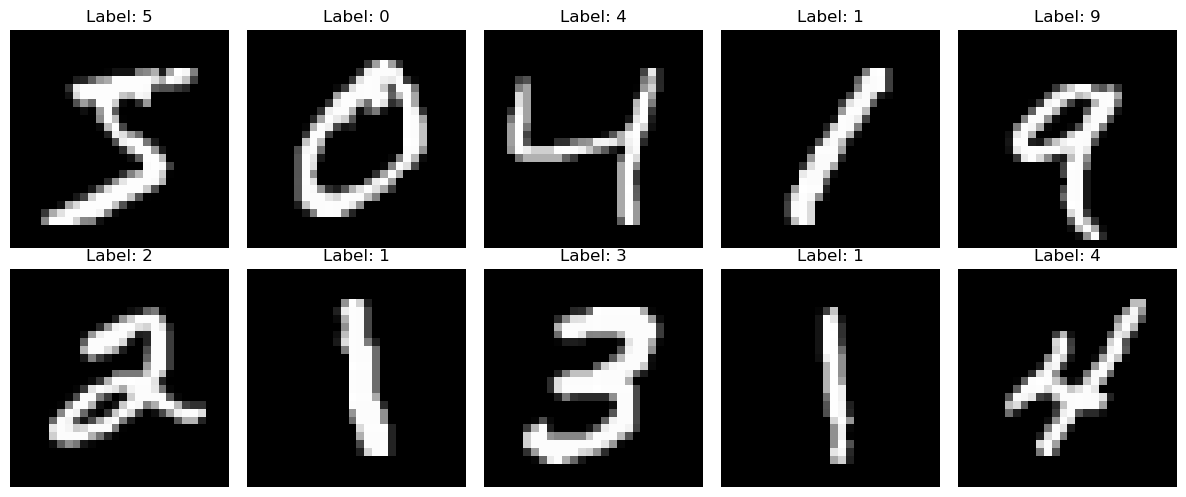

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


In [20]:
# Load MNIST dataset
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.1307,), (0.3081,)) # MNIST mean and std
])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)
# Visualize some examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

In [21]:
#model 
mlp_model = MultiLayerPerceptron().to(DEVICE)
mlp_model

MultiLayerPerceptron(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [22]:
#number of parameters
total_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params}")

Total Trainable Parameters: 235146


In [23]:
#training the model

mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr= 0.01)
mlp_criterion = torch.nn.CrossEntropyLoss()
mlp_epoches = 5

mlp_dict = {"loss": [], 
            "accuracy": [], 
            "epoch": []}

for epoch in range(mlp_epoches):
    #eval metrics
    mlp_model.train()
    running_loss = 0.0
    total = 0 
    correct = 0
    #looping over train loader
    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        #reset gradients
        mlp_optimizer.zero_grad()
        mlp_output = mlp_model.forward(images)
        mlp_loss = mlp_criterion(mlp_output, labels)
        mlp_loss.backward()
        mlp_optimizer.step()

        #recording metrics
        running_loss += mlp_loss.item() * labels.size(0)
        preds = mlp_output.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    #calculating average metrics
    train_loss = running_loss/total
    train_acc = correct / total
    mlp_dict["accuracy"].append(train_acc)
    mlp_dict["loss"].append(train_loss)
    mlp_dict["epoch"].append(epoch+ 1)
    print(f"Epoch {epoch+1}: loss={train_loss:.4f}, acc={train_acc:.4f}")

mlp_model.eval()

Epoch 1: loss=0.2958, acc=0.9130
Epoch 2: loss=0.2011, acc=0.9462
Epoch 3: loss=0.1785, acc=0.9533
Epoch 4: loss=0.1626, acc=0.9578
Epoch 5: loss=0.1638, acc=0.9584


MultiLayerPerceptron(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [24]:
df3 = pd.DataFrame(mlp_dict)

fig = go.Figure()
fig.add_scatter(
    x=df3["epoch"],
    y=df3["loss"],
    mode="lines",
    marker=dict(color="#1f77b4"),
    name="Adam loss",
)
fig.add_scatter(
    x=df3["epoch"],
    y=df3["accuracy"],
    mode="lines",
    line=dict(color="orange"),
    name="Accuracry",
)
fig.update_layout(showlegend=True)
fig.show()

Predictions: [7 2 1 0 4 1 4 9 5 9]
Ground truth: [7 2 1 0 4 1 4 9 5 9]


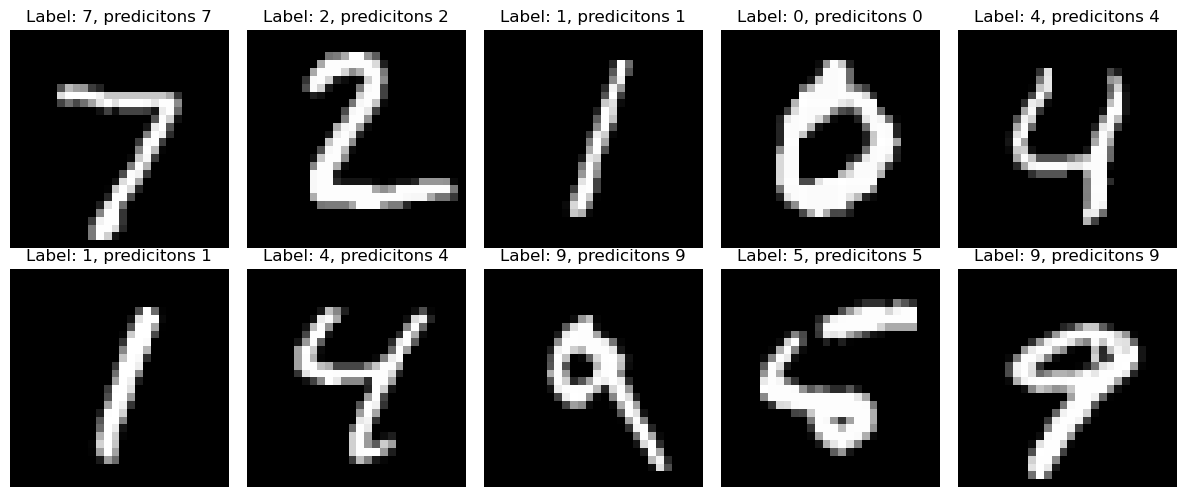

In [34]:
#testing model with test set 

with torch.no_grad():
    images, labels = next(iter(test_loader))
    images = images[:10].to(DEVICE)            
    labels = labels[:10].to(DEVICE)
    output = mlp_model.forward(images)
    pred = output.argmax(dim=1)
    print("Predictions:", pred.cpu().numpy())
    print("Ground truth:", labels.cpu().numpy())



fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = test_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}, predicitons {pred[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()
